# RSA Listener Fitting
**listener_logit / listener_choice → pRRSAc / pRRSAf 파라미터 추정**

| 모델 | 데이터 | 스케일 | RSA | Likelihood |
|------|--------|--------|-----|------------|
| E | listener_logit  | log P_LLM(s\|u,r) | pRRSAc | Normal(log P_L1 + c, σ) |
| F | listener_logit  | log P_LLM(s\|u,r) | pRRSAf | Normal(log P_L1 + c, σ) |
| G | listener_choice | count(s\|u,r)     | pRRSAc | Multinomial(P_L1) |
| H | listener_choice | count(s\|u,r)     | pRRSAf | Multinomial(P_L1) |

$$P_{L1}(s \mid u,r) \propto P(s) \cdot P_{S1}(u \mid s,r)$$
$$U_{\text{pRRSAc}}(u,s,r) = \phi_r\,U_{\text{epi}}(u,s) + (1-\phi_r)\,U_{\text{soc}}(u)$$
$$U_{\text{pRRSAf}}(u,s,r) = U_{\text{epi}}(u,s) + \alpha_r \cdot U_{\text{soc}}(u)$$

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from pathlib import Path

from variables import ADJECTIVES, RELATIONSHIP_VAR, STATE_VAR

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# ── CONFIG ──────────────────────── (여기만 수정)
MODEL       = "llama3_zero"   # "llama3" | "qwen3"
MCMC_DRAWS  = 2000
MCMC_TUNE   = 1000
MCMC_CHAINS = 4
# ────────────────────────────────────────────────

UTTERANCES = ADJECTIVES
STATES     = STATE_VAR
RELATIONS  = RELATIONSHIP_VAR
N_utt = len(UTTERANCES)
N_sta = len(STATES)
N_rel = len(RELATIONS)
print(f"model={MODEL}")

model=llama3_zero


---
## Step 1 — Semantics & L0
$$P_{L_0}(s \mid u) \propto [\![u]\!](s) \cdot P(s)$$

In [3]:
#                  s=1   s=2   s=3   s=4   s=5
SEM = np.array([
    [0.00, 0.03, 0.06, 0.16, 1.00],   # großartig
    [0.03, 0.03, 0.66, 1.00, 0.90],   # gut
    [0.06, 0.47, 1.00, 0.66, 0.47],   # okay
    [0.91, 0.59, 0.06, 0.00, 0.00],   # schlecht
    [0.84, 0.25, 0.00, 0.00, 0.00],   # schrecklich
], dtype=float)

SEM = np.maximum(SEM, 0.01)
prior_s = np.ones(N_sta) / N_sta
L0 = SEM * prior_s[np.newaxis, :]
L0 = L0 / L0.sum(axis=1, keepdims=True)

print("L0 — P_L0(s | u):")
pd.DataFrame(L0, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3)

L0 — P_L0(s | u):


,s=1,s=2,s=3,s=4,s=5
großartig,0.008,0.024,0.048,0.127,0.794
gut,0.011,0.011,0.252,0.382,0.344
okay,0.023,0.177,0.376,0.248,0.177
schlecht,0.576,0.373,0.038,0.006,0.006
schrecklich,0.750,0.223,0.009,0.009,0.009


## Step 2 — Utilities

We first define a **value function** that assigns a desirability score to each state:

$$V(s) = \alpha \cdot s$$

where $\alpha \geq 0$ scales how strongly higher states are preferred. The speaker then weighs two competing utilities for each utterance.

**Epistemic utility** — how well the utterance conveys the intended state $s$ (depends on $s$):

$$U_{\text{epi}}(u, s) = \log P_{L_0}(s \mid u)$$

**Social utility** — the expected desirability of the state the listener infers from $u$ (depends only on $u$, not on the intended $s$):

$$U_{\text{soc}}(u) = \mathbb{E}_{P_{L_0}(s \mid u)}\big[V(s)\big] = \sum_{s'} P_{L_0}(s' \mid u) \cdot V(s') = \alpha \sum_{s'} P_{L_0}(s' \mid u) \cdot s'$$

In our implementation $\alpha$ will be inferenced 나중에, so the code computes $U_{\text{soc}}(u) = \sum_{s'} P_{L_0}(s' \mid u)\cdot s'$ first. This is justified for pRRSAc, where $\alpha$ is non-identifiable and absorbed into $\phi$ within the softmax. For pRRSAf, the relationship-specific $\alpha_r$ is instead applied when the two utilities are combined.

In [17]:
state_vals = np.array(STATES, dtype=float)

U_epi = np.log(L0 + 1e-10)                        # (N_utt, N_sta)

# α를 곱하지 않은 "base" U_soc — α는 나중에 MCMC에서 곱함
U_soc_base = (L0 * state_vals[np.newaxis, :]).sum(1)   # (N_utt,)
# U_soc(u) = α * U_soc_base(u)  ← α는 PyMC 안에서 곱해짐

print("U_epi:")
print(pd.DataFrame(U_epi, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3).to_string())
print("\nU_soc_base (α=1 for now, alpha will be multiplied afterwards):")
for u, v in zip(UTTERANCES, U_soc_base):
    print(f"  {u:12s}: {v:.3f}  {'█'*int(v*5)}")

U_epi:
               s=1    s=2    s=3    s=4    s=5
großartig   -4.836 -3.738 -3.045 -2.064 -0.231
gut         -4.470 -4.470 -1.379 -0.963 -1.069
okay        -3.792 -1.733 -0.978 -1.394 -1.733
schlecht    -0.552 -0.985 -3.271 -5.063 -5.063
schrecklich -0.288 -1.500 -4.718 -4.718 -4.718

U_soc_base (α=1 for now, alpha will be multiplied afterwards):
  großartig   : 4.675  ███████████████████████
  gut         : 4.034  ████████████████████
  okay        : 3.380  ████████████████
  schlecht    : 1.494  ███████
  schrecklich : 1.304  ██████


In [39]:
print(state_vals)
print(L0)

[1. 2. 3. 4. 5.]
[[0.00793651 0.02380952 0.04761905 0.12698413 0.79365079]
 [0.01145038 0.01145038 0.2519084  0.38167939 0.34351145]
 [0.02255639 0.17669173 0.37593985 0.2481203  0.17669173]
 [0.57594937 0.37341772 0.03797468 0.00632911 0.00632911]
 [0.75       0.22321429 0.00892857 0.00892857 0.00892857]]


---
## Step 3 — Data Loading

In [18]:
def _parse_state(text):
    m = re.search(r'[1-5]', str(text))
    return int(m.group()) if m else None


def flat_listener_logit(model):
    """
    각 CSV 행(situation × rep) × 5상태 = 독립 관측치
    logprob_: 5개 후보 내 renormalized log-prob = log P_LLM(s|u,r) 스케일
    반환: (rel_idx, utt_idx, sta_idx, obs)
    """
    p = Path(f'results/listener_logit_{model}.csv')
    if not p.exists():
        print(f'[없음] {p}'); return None
    df = pd.read_csv(p)
    rows = []
    for _, row in df.iterrows():
        try:
            r_i = RELATIONS.index(row['relationship'])
            u_i = UTTERANCES.index(row['adjective'])
        except ValueError:
            continue
        for s_i, sta in enumerate(STATES):
            col = f'logprob_{sta}'
            if col not in df.columns: continue
            rows.append({'rel_idx': r_i, 'utt_idx': u_i,
                         'sta_idx': s_i, 'obs': float(row[col])})
    df_f = pd.DataFrame(rows)
    n_cond = N_rel * N_utt * N_sta
    print(f'flat_listener_logit_{model}: {len(df_f)} obs '
          f'({len(df_f)//n_cond} per condition)')
    return (df_f['rel_idx'].values.astype(int),
            df_f['utt_idx'].values.astype(int),
            df_f['sta_idx'].values.astype(int),
            df_f['obs'].values)


def load_listener_counts(model):
    """counts_listener[r, u, s] — situation+rep 합산"""
    p = Path(f'results/listener_choice_{model}.csv')
    if not p.exists(): return print(f'[없음] {p}')
    df = pd.read_csv(p)
    df['inferred'] = df['response_text'].apply(_parse_state)
    n_fail = df['inferred'].isna().sum()
    print(f'파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)')
    df = df.dropna(subset=['inferred'])
    df['inferred'] = df['inferred'].astype(int)
    out = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            mask = (df['relationship'] == rel) & (df['adjective'] == adj)
            for s_i, sta in enumerate(STATES):
                out[r_i, u_i, s_i] = (df.loc[mask, 'inferred'] == sta).sum()
    print(f'listener_counts_{model}: {out.shape}, total={out.sum():.0f}')
    return out

In [19]:

flat_li         = flat_listener_logit(MODEL)    # (rel,utt,sta,obs) | None
counts_listener = load_listener_counts(MODEL)   # (N_rel,N_utt,N_sta) | None

flat_listener_logit_llama3_zero: 500 obs (5 per condition)
파싱 실패: 0/1000 (0.0%)
listener_counts_llama3_zero: (4, 5, 5), total=1000


---
## Step 4 — PyMC Forward Models

```
build_rsa   → pRRSAc: U = φ·U_epi + (1-φ)·U_soc
→ log_L1[r, u, s] = log P_L1(s | u, r)  (state 축 정규화)
```

In [20]:
def build_rsa_c(phi, alpha, lam):
    """pRRSAc → log_S1, log_L1: (N_rel, N_utt, N_sta)"""
    L0_t    = pt.as_tensor_variable(L0)
    U_epi_t = pt.as_tensor_variable(U_epi)
    U_soc_base = pt.dot(L0_t, pt.as_tensor_variable(state_vals))  # (N_utt,)
    U_soc_t   = alpha * U_soc_base 
    phi_b   = phi[:, None, None] # (N_rel, 1, 1)
    U = phi_b * U_epi_t[None,:,:] + (1-phi_b) * U_soc_t[None,:,None]
    logits  = lam * U
    log_S1  = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1  = log_S1 - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


def build_rsa_f(phi, alpha, lam):
    """pRRSAf → log_S1, log_L1: (N_rel, N_utt, N_sta)"""
    L0_t    = pt.as_tensor_variable(L0)
    U_epi_t = pt.as_tensor_variable(U_epi)
    U_soc_t = pt.dot(L0_t, pt.as_tensor_variable(state_vals))
    alpha_b = alpha[:, None, None]
    U = U_epi_t[None,:,:] + alpha_b * U_soc_t[None,:,None]
    logits  = lam * U
    log_S1  = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1  = log_S1 - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


print('build_rsa_c / build_rsa_f 정의 완료')

build_rsa_c / build_rsa_f 정의 완료


---
## Step 5 — Sanity Check

In [25]:
def load_listener_logit_avg(model):
    """[sanity/PPC 전용] situation 평균 logprobs_listener[r, u, s]"""
    p = Path(f'results/listener_logit_{model}.csv')
    if not p.exists(): return print(f'[없음] {p}')
    df = pd.read_csv(p)
    out = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            mask = (df['relationship'] == rel) & (df['adjective'] == adj)
            for s_i, sta in enumerate(STATES):
                out[r_i, u_i, s_i] = df.loc[mask, f'logprob_{sta}'].mean()
    print(f'listener_logit_avg_{model}: {out.shape}  ※ sanity/PPC 전용')
    return out


logprobs_li_avg = load_listener_logit_avg(MODEL)   # sanity/PPC 전용


def rsa_listener_np(u_idx, phi, alpha=1.0, lam=1.0):
    """numpy 버전 L1(s|u) — sanity/PPC 전용"""
    U_soc_np = np.array(U_soc).flatten()   # (N_utt,)
    utility = phi * U_epi + (1 - phi) * U_soc_np[:, None]   # (N_utt, N_sta)
    logits  = lam * utility
    # S1: utterance 축 정규화
    S1 = np.exp(logits - logits.max(axis=0, keepdims=True))
    S1 /= S1.sum(axis=0, keepdims=True)
    # L1: state 축 정규화
    L1 = S1 / S1.sum(axis=1, keepdims=True)
    return L1[u_idx, :]   # (N_sta,)


if logprobs_li_avg is not None:
    rsa_lp, llm_lp = [], []
    for r_i in range(N_rel):
        for u_i in range(N_utt):
            p = rsa_listener_np(u_i, phi=0.4, alpha=1.0, lam=1.0)
            for s_i in range(N_sta):
                rsa_lp.append(np.log(p[s_i] + 1e-10))
                llm_lp.append(logprobs_li_avg[r_i, u_i, s_i])
    rsa_lp, llm_lp = np.array(rsa_lp), np.array(llm_lp)
    r = np.corrcoef(rsa_lp, llm_lp)[0, 1]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rsa_lp, llm_lp, alpha=0.3, s=15)
    lim = [min(rsa_lp.min(), llm_lp.min())-0.3, max(rsa_lp.max(), llm_lp.max())+0.3]
    ax.plot(lim, lim, 'r--', lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('RSA log P_L1 (φ=0.4, λ=1.0)')
    ax.set_ylabel('LLM log P(s|u,r)')
    ax.set_title(f'Sanity Check  r={r:.3f}')
    plt.tight_layout()
    plt.savefig(f'results/sanity_listener_{MODEL}.png', dpi=150)
    plt.show()

listener_logit_avg_llama3_zero: (4, 5, 5)  ※ sanity/PPC 전용


TypeError: Variables do not support boolean operations.

In [23]:
print(type(U_soc), U_soc.shape)

<class 'pytensor.tensor.variable.TensorVariable'> Shape.0


In [13]:
# φ 범위 스캔해서 최대 r 찾기
best_r, best_phi = -1, 0
for phi_test in np.arange(0.1, 1.0, 0.1):
    rsa_lp = []
    for r_i in range(N_rel):
        for u_i in range(N_utt):
            p = rsa_listener_np(u_i, phi=phi_test, lam=1.0)
            for s_i in range(N_sta):
                rsa_lp.append(np.log(p[s_i] + 1e-10))
    r_val = np.corrcoef(rsa_lp, llm_lp)[0, 1]
    print(f"φ={phi_test:.1f}  r={r_val:.3f}")
    if r_val > best_r:
        best_r, best_phi = r_val, phi_test

print(f"\n최적 φ={best_phi:.1f}  r={best_r:.3f}")

φ=0.1  r=0.387
φ=0.2  r=0.358
φ=0.3  r=0.339
φ=0.4  r=0.335
φ=0.5  r=0.347
φ=0.6  r=0.370
φ=0.7  r=0.398
φ=0.8  r=0.425
φ=0.9  r=0.447

최적 φ=0.9  r=0.447


---
## Model E — Listener Logit pRRSAc
$$\log P_{\text{LLM}}(s \mid u,r) \sim \mathcal{N}(\log P_{L1}(s \mid u,r) + c,\;\sigma)$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha   0.176  0.232   0.000    0.553      0.004    0.003    2479.0    2722.0   
phi[0]  0.846  0.136   0.596    1.000      0.004    0.002    1531.0    1903.0   
phi[1]  0.807  0.145   0.548    1.000      0.004    0.003    1777.0    2013.0   
phi[2]  0.691  0.157   0.437    0.998      0.004    0.003    1862.0    2263.0   
phi[3]  0.567  0.153   0.282    0.861      0.003    0.002    2272.0    2711.0   
lam     0.853  0.227   0.569    1.205      0.007    0.005    1535.0    1801.0   
c      -0.924  0.111  -1.127   -0.711      0.001    0.001    6086.0    5743.0   
sigma   2.042  0.064   1.919    2.162      0.001    0.001    5988.0    5291.0   

        r_hat  
alpha     1.0  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
lam       1.0  
c         1.0  
sigma     1.0  


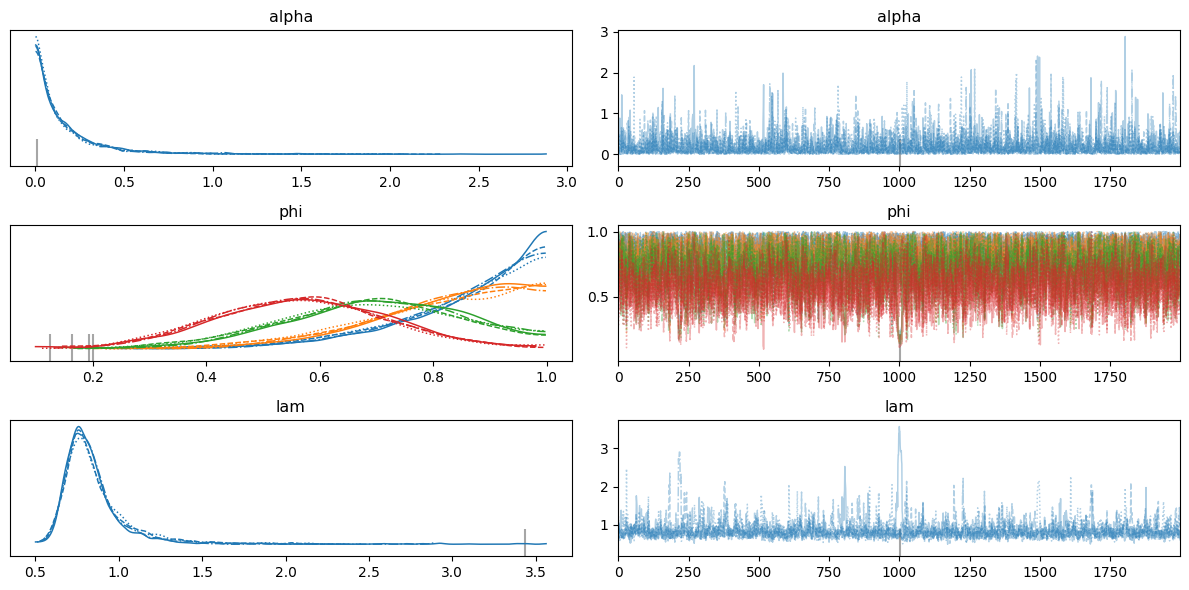

In [26]:
trace_E = None

if flat_li is None:
    print('[skip] listener_logit 없음')
else:
    rel_idx_li, utt_idx_li, sta_idx_li, obs_li = flat_li

    with pm.Model() as model_E:
        alpha = pm.Uniform("alpha", lower=0, upper=5)
        U_soc = alpha * pt.as_tensor_variable(U_soc_base)  # 여기서 α 곱함
        phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
        lam   = pm.Uniform('lam',   lower=0, upper=20)
        c     = pm.Normal('c',      mu=0,    sigma=3)
        sigma = pm.HalfNormal('sigma', sigma=1)

        _, log_L1 = build_rsa_c(phi, alpha, lam)
        mu = log_L1[rel_idx_li, utt_idx_li, sta_idx_li] + c
        pm.Normal('obs', mu=mu, sigma=sigma, observed=obs_li)

    with model_E:
        trace_E = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_E, var_names=['alpha','phi', 'lam', 'c', 'sigma']))
    az.plot_trace(trace_E, var_names=['alpha','phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model G — Listener Choice pRRSAc (Multinomial)
$$\text{count}(s \mid u,r) \sim \text{Multinomial}(N,\;P_{L1}(s \mid u,r))$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha   0.210  0.090   0.045    0.374      0.003    0.002     872.0     753.0   
phi[0]  0.759  0.153   0.491    1.000      0.006    0.004     712.0     717.0   
phi[1]  0.715  0.146   0.434    0.960      0.006    0.004     724.0     708.0   
phi[2]  0.689  0.141   0.428    0.961      0.005    0.004     735.0     697.0   
phi[3]  0.356  0.087   0.194    0.520      0.003    0.002     772.0     689.0   
lam     3.407  1.152   2.201    5.115      0.052    0.039     696.0     662.0   

        r_hat  
alpha    1.01  
phi[0]   1.01  
phi[1]   1.01  
phi[2]   1.01  
phi[3]   1.01  
lam      1.01  


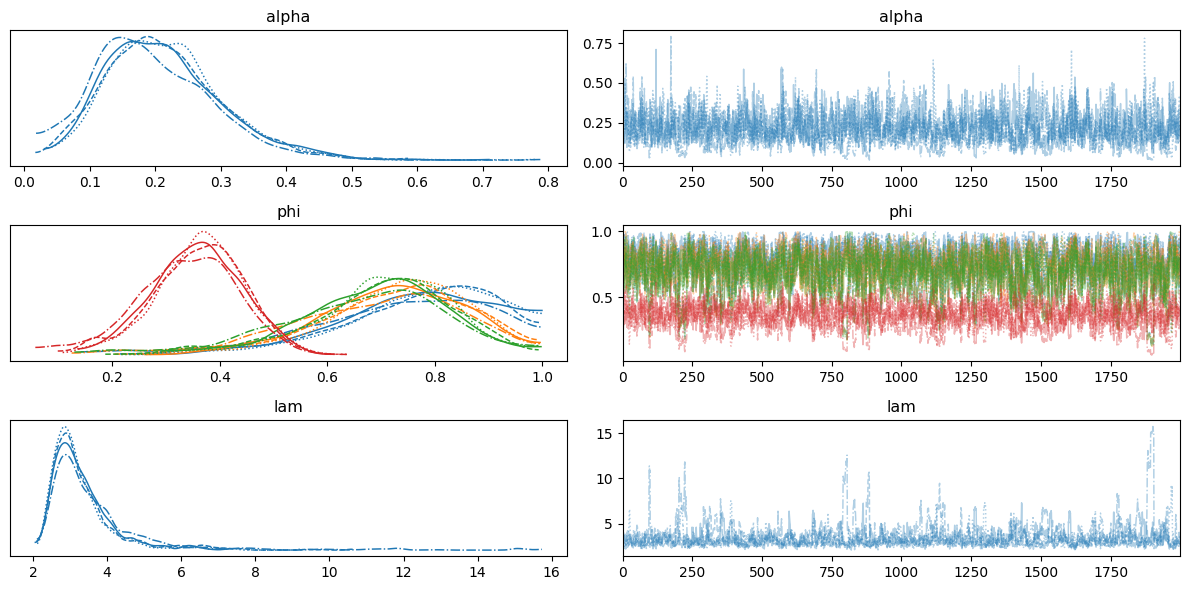

In [27]:
trace_G = None

if counts_listener is None:
    print('[skip] listener_choice 없음')
else:
    n_li = counts_listener.sum(axis=-1)   # (N_rel, N_utt)

    with pm.Model() as model_G:
        alpha = pm.Uniform("alpha", lower=0, upper=5)
        U_soc = alpha * pt.as_tensor_variable(U_soc_base)  # 여기서 α 곱함
        phi = pm.Uniform('phi', lower=0, upper=1, shape=N_rel)
        lam = pm.Uniform('lam', lower=0, upper=20)

        _, log_L1 = build_rsa_c(phi, alpha,lam)
        P_L1 = pt.exp(log_L1)   # (N_rel, N_utt, N_sta)
        pm.Multinomial('obs', n=n_li, p=P_L1, observed=counts_listener)

    with model_G:
        trace_G = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_G, var_names=['alpha','phi','lam']))
    az.plot_trace(trace_G, var_names=['alpha','phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Step 5 — HUMAN REFERENCE (Lumer et al.)

In [33]:
HUMAN_LAM_C = 4.59
HUMAN_LAM_F = 2.25

HUMAN_PHI_C = {
    'Enge Freundin':      0.45,
    'Entfernte Kollegin': 0.31,
    'Lockere Chefin':     0.371,
    'Gefürchtete Chefin': 0.22,
}
HUMAN_PHI_F = 0.69

HUMAN_ALPHA_C = 0.61
HUMAN_ALPHA_F = {
    'Enge Freundin':      1.88,
    'Entfernte Kollegin': 2.90,
    'Lockere Chefin':     1.97,
    'Gefürchtete Chefin': 4.63,
}

HUMAN_TABLE_MEAN = {
    ('Enge Freundin',      'großartig'): 4.80, 
    ('Enge Freundin',      'gut'): 3.31,
    ('Enge Freundin',      'okay'): 2.38,      
    ('Enge Freundin',      'schlecht'): 1.12,
    ('Enge Freundin',      'schrecklich'): 1.18,
    ('Entfernte Kollegin', 'großartig'): 4.31, ('Entfernte Kollegin', 'gut'): 2.91,
    ('Entfernte Kollegin', 'okay'): 2.04,      ('Entfernte Kollegin', 'schlecht'): 1.26,
    ('Entfernte Kollegin', 'schrecklich'): 1.04,
    ('Lockere Chefin',     'großartig'): 4.46, ('Lockere Chefin',     'gut'): 3.27,
    ('Lockere Chefin',     'okay'): 2.30,      ('Lockere Chefin',     'schlecht'): 1.25,
    ('Lockere Chefin',     'schrecklich'): 1.07,
    ('Gefürchtete Chefin', 'großartig'): 3.69, ('Gefürchtete Chefin', 'gut'): 2.59,
    ('Gefürchtete Chefin', 'okay'): 1.67,      ('Gefürchtete Chefin', 'schlecht'): 1.19,
    ('Gefürchtete Chefin', 'schrecklich'): 1.11,
}
print('인간 레퍼런스 로드 완료')

인간 레퍼런스 로드 완료


---
## Step 6 — 결과 비교

In [34]:
# ── 수렴 진단 ─────────────────────────────────────────────────────────────────
TRACES = {
    'E: Listener Logit  pRRSAc': (trace_E, 'phi'),
    'G: Listener Choice pRRSAc': (trace_G, 'phi'),
}
for name, (trace, pname) in TRACES.items():
    if trace is None:
        print(f'  {name:<32} [skip]'); continue
    rhat_vals = [float(az.rhat(trace)[v].values.max())
                 for v in [pname, 'lam'] if v in trace.posterior]
    max_r = max(rhat_vals) if rhat_vals else float('nan')
    status = '✓' if max_r < 1.01 else '△' if max_r < 1.05 else '✗'
    print(f'{status} {name:<32} max R-hat = {max_r:.4f}')

✓ E: Listener Logit  pRRSAc        max R-hat = 1.0022
△ G: Listener Choice pRRSAc        max R-hat = 1.0105


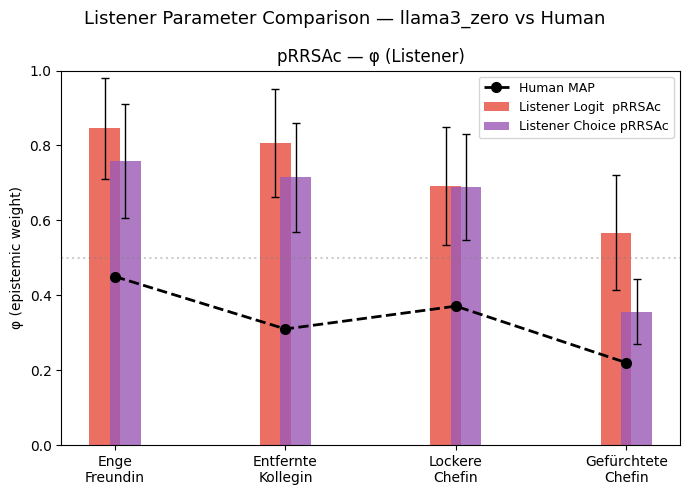

In [35]:
# ── φ / α 비교 플롯 ───────────────────────────────────────────────────────────
phi_traces   = {k: tr for k, (tr, param) in TRACES.items()
                if tr is not None and param == 'phi'   and 'phi'   in tr.posterior}

n_plots = (1 if phi_traces else 0) 
if n_plots == 0:
    print('[skip]')
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1: axes = [axes]
    ax_idx = 0
    labels = [r.replace(' ', '\n') for r in RELATIONS]
    x = np.arange(N_rel); width = 0.18

    colors = {
        'E: Listener Logit  pRRSAc': '#e74c3c', # red
        'G: Listener Choice pRRSAc': '#9b59b6', # purple
        'F: Listener Logit  pRRSAf': '#e74c3c', # red
        'H: Listener Choice pRRSAf': '#34495e', # dark gray
    }

    if phi_traces:
        ax = axes[ax_idx]; ax_idx += 1
        offsets = np.linspace(-len(phi_traces)*width/2, len(phi_traces)*width/2,
                              len(phi_traces)+2)[1:-1]
        for i, (key, tr) in enumerate(phi_traces.items()):
            samp = tr.posterior['phi'].values          # shape: (chain, draw, N_rel)
            m = samp.mean(axis=(0, 1))
            s = samp.std(axis=(0, 1))
            label = key.split(': ', 1)[1]
            ax.bar(x+offsets[i], m, width, label=label, color=colors[key], alpha=0.8)
            ax.errorbar(x+offsets[i], m, s, fmt='none', color='black', capsize=3, lw=1)
        ax.plot(x, [HUMAN_PHI_C[r] for r in RELATIONS], 'k--o', lw=2, ms=7, label='Human MAP')
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('φ (epistemic weight)'); ax.set_ylim(0, 1)
        ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
        ax.legend(fontsize=9); ax.set_title('pRRSAc — φ (Listener)')

    fig.suptitle(f'Listener Parameter Comparison — {MODEL} vs Human', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'results/listener_params_{MODEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [37]:
# ── Listener 추론 분포: E[s | u, r] ──────────────────────────────────────────
def compute_L1_np(phi_dict, alpha, lam):
    """alpha를 인자로 받아서 numpy로 U_soc 계산"""
    # pytensor 오염 방지 - numpy로 계산
    U_epi_np = np.array(U_epi, dtype=float)  # (N_utt, N_sta)
    U_soc_np = np.array(U_soc, dtype=float).flatten() # (N_utt,)
    alpha_np = float(alpha)  # scalar
    lam_np = float(lam)        # scalar
    
    U_soc_scaled = alpha_np * U_soc_np  # U_soc는 미리 계산된 base (Σ P_L0(s'|u)·s')
    L1_all = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        phi = phi_dict[rel]
        for s_i in range(N_sta):
            u_e = U_epi[:, s_i]
            utility = phi * u_e + (1-phi) * U_soc_scaled
            logits = lam * utility
            logits -= logits.max()
            S1_col = np.exp(logits)
            S1_col /= S1_col.sum()
            L1_all[r_i, :, s_i] = S1_col
        L1_all[r_i] = L1_all[r_i] / L1_all[r_i].sum(axis=1, keepdims=True)
    return L1_all


# TRACES에서 phi 기반 모델만 추출...왜? 
phi_model_traces = {k: tr for k, (tr, param) in TRACES.items()
                    if tr is not None and param == 'phi' and 'phi' in tr.posterior}

if phi_model_traces:
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#1abc9c']   
    # 모델 수만큼 확장 가능,  [ blue, purple, red, green]
    L1_hum = compute_L1_np(HUMAN_PHI_C, HUMAN_ALPHA_C, HUMAN_LAM_C)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (r_i, rel) in zip(axes.flatten(), enumerate(RELATIONS)):
        e_hum    = (L1_hum[r_i] * state_vals[np.newaxis,:]).sum(1)
        human_exp = [HUMAN_TABLE_MEAN.get((rel, u), np.nan) for u in UTTERANCES]

        # LLM 추정값
        for ci, (key, tr) in enumerate(phi_model_traces.items()):
            summ = az.summary(tr, var_names=['phi', 'alpha', 'lam'])  # ← alpha 추가
            phi_est = {rel_: summ.loc[f'phi[{i}]', 'mean'] for i, rel_ in enumerate(RELATIONS)}
            alpha_est = summ.loc['alpha', 'mean']                      # ← 추가
            lam_est = summ.loc['lam', 'mean']
            L1_est = compute_L1_np(phi_est, alpha_est, lam_est)        # ← alpha_est 전달

        ax.plot(UTTERANCES, e_hum,     's--', color='#e67e22', lw=2, ms=7, label='Human MAP')
        ax.plot(UTTERANCES, human_exp, '^:',  color='#27ae60', lw=2, ms=7, label='Human Mean')
        ax.set_title(rel, fontweight='bold')
        ax.set_ylim(1, 5.3); ax.set_ylabel('E[s | u, r]')
        ax.tick_params(axis='x', rotation=25); ax.axhline(3, color='gray', ls=':', alpha=0.3)

    axes[0,0].legend(fontsize=9)
    fig.suptitle(f'Listener E[s|u,r] — {MODEL} vs Human', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'results/listener_inferred_state_{MODEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

ValueError: setting an array element with a sequence.

---
## Step 9 — Posterior Predictive Check (Model E)

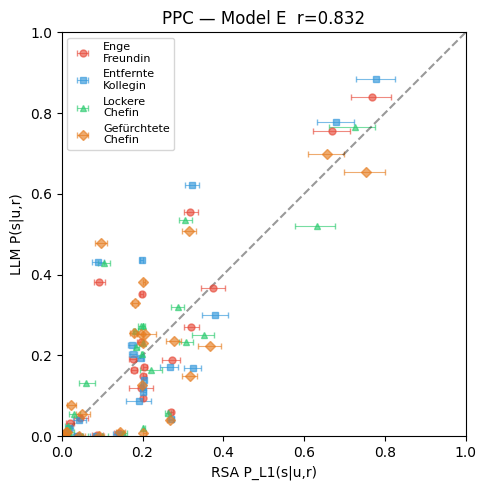

In [49]:
# ── Posterior Predictive Check (Model E) ──────────────────────────────────────
if trace_E is None or logprobs_li_avg is None:
    print('[skip]')
else:
    lam_s = trace_E.posterior['lam'].values.flatten()
    phi_s = trace_E.posterior['phi'].values.reshape(-1, N_rel)
    n_samp = min(len(lam_s), 500)   # 속도 위해 500개

    ppc_rows = []
    for r_i, rel in enumerate(RELATIONS):
        for u_i, utt in enumerate(UTTERANCES):
            probs_obs = np.exp(logprobs_li_avg[r_i, u_i, :])
            probs_obs /= probs_obs.sum()
            for s_i in range(N_sta):
                preds = np.array([
                    rsa_listener_np(u_i, phi=phi_s[j, r_i], lam=lam_s[j])[s_i]
                    for j in range(n_samp)
                ])
                ppc_rows.append({
                    'relationship': rel,
                    'prob_obs':     probs_obs[s_i],
                    'pred_mean':    preds.mean(),
                    'pred_lo':      np.percentile(preds, 3),
                    'pred_hi':      np.percentile(preds, 97),
                })

    df_ppc = pd.DataFrame(ppc_rows)
    colors  = dict(zip(RELATIONS, ['#e74c3c', '#3498db', '#2ecc71', '#e67e22']))
    markers = dict(zip(RELATIONS, ['o', 's', '^', 'D']))

    fig, ax = plt.subplots(figsize=(5, 5))
    for rel in RELATIONS:
        d = df_ppc[df_ppc['relationship'] == rel]
        ax.errorbar(
            d['pred_mean'], d['prob_obs'],
            xerr=[d['pred_mean']-d['pred_lo'], d['pred_hi']-d['pred_mean']],
            fmt=markers[rel], color=colors[rel],
            label=rel.replace(' ', '\n'), alpha=0.65, ms=5, capsize=2, lw=0.8,
        )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    r_ppc = np.corrcoef(df_ppc['pred_mean'], df_ppc['prob_obs'])[0, 1]
    ax.set_title(f'PPC — Model E  r={r_ppc:.3f}')
    ax.set_xlabel('RSA P_L1(s|u,r)')
    ax.set_ylabel('LLM P(s|u,r)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'results/listener_ppc_{MODEL}.png', dpi=150)
    plt.show()

이 스크립트는 rsa_modeling.ipynb에서 %run 으로 실행하세요.
필요 변수: TRACES, RELATIONS, MODEL

사용 예시:
  %run analysis_phi_convergence.py
  run_phi_convergence_analysis(TRACES, RELATIONS, MODEL)
φ 수렴 분석 대상 모델 (2개):
  • E: Listener Logit  pRRSAc
  • G: Listener Choice pRRSAc

  수렴 요약 테이블  (mean ± SD  [95% HDI])

  관계: Enge Freundin
    Listener Logit  pRRSAc               0.957 ± 0.042  [0.875, 1.000]
    Listener Choice pRRSAc               0.741 ± 0.384  [0.057, 1.000]

  관계: Entfernte Kollegin
    Listener Logit  pRRSAc               0.933 ± 0.060  [0.813, 1.000]
    Listener Choice pRRSAc               0.714 ± 0.363  [0.064, 0.998]

  관계: Lockere Chefin
    Listener Logit  pRRSAc               0.856 ± 0.113  [0.636, 1.000]
    Listener Choice pRRSAc               0.701 ± 0.354  [0.061, 0.986]

  관계: Gefürchtete Chefin
    Listener Logit  pRRSAc               0.673 ± 0.163  [0.378, 0.989]
    Listener Choice pRRSAc               0.405 ± 0.290  [0.040, 0.731]

  95% HDI 겹침 여부  (✓=겹침 / ✗=안겹침)

  Enge Fre

/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_c

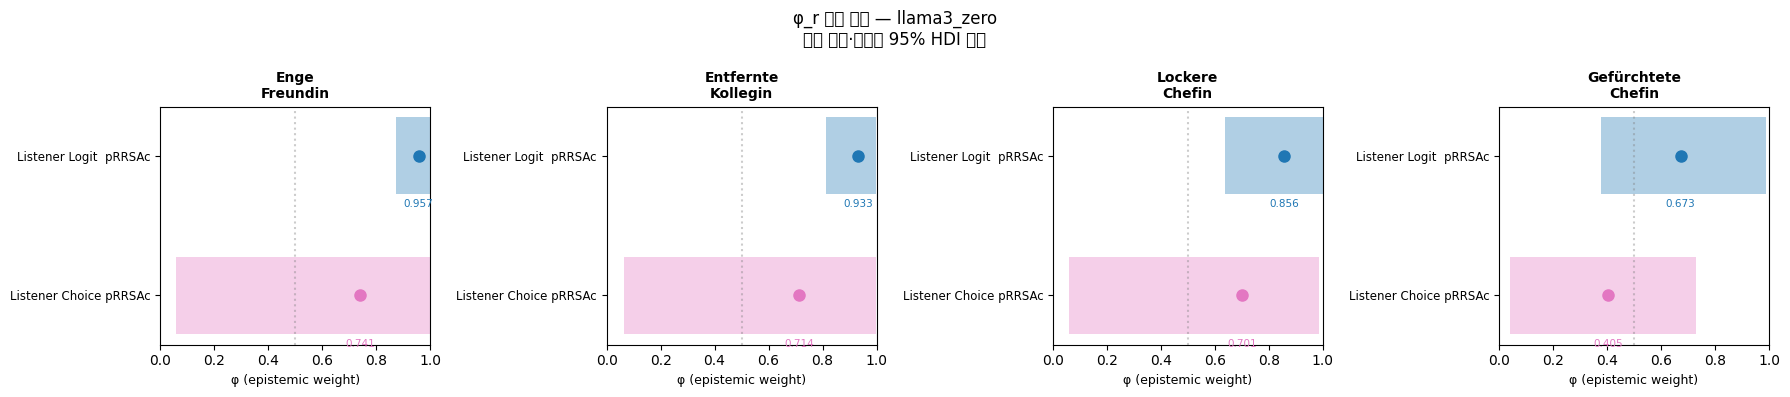

  저장: results/phi_convergence_forest_llama3_zero.png

  φ_r 패턴 방향성 (관계별 순위  낮을수록 face-saving)
  Listener Logit  pRRSAc
    face-saving ← Gefürchtete Chefin  <  Lockere Chefin  <  Entfernte Kollegin  <  Enge Freundin → epistemic
    순위: Enge Freundi=4  |  Entfernte Ko=3  |  Lockere Chef=2  |  Gefürchtete =1
  Listener Choice pRRSAc
    face-saving ← Gefürchtete Chefin  <  Lockere Chefin  <  Entfernte Kollegin  <  Enge Freundin → epistemic
    순위: Enge Freundi=4  |  Entfernte Ko=3  |  Lockere Chef=2  |  Gefürchtete =1

  자동 결론

  전체 모델 쌍 × 관계 조합: 4개
  HDI 겹침: 4/4 (100%)

  판정: 수렴 (convergent)
  해석: φ_r 추정값이 측정 방법·방향에 무관하게 일관되게 수렴한다.

  관계별 수렴도:
    Enge Freundin             1/1 (100%)  ████████████████████
    Entfernte Kollegin        1/1 (100%)  ████████████████████
    Lockere Chefin            1/1 (100%)  ████████████████████
    Gefürchtete Chefin        1/1 (100%)  ████████████████████


In [32]:
# rsa_modeling.ipynb 하단 셀에 추가
%run analysis_phi_convergence.py
df_summ, df_ov = run_phi_convergence_analysis(TRACES, RELATIONS, MODEL)